<a href="https://colab.research.google.com/github/anshi611/Applied-Machine-Learning-Lab/blob/main/Experiment01_Retail_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("retail_data.csv")

In [5]:
df

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,ProductCategory,ProductPrice,PurchaseDate,StoreID,StoreLocation,PaymentMethod,DiscountApplied,DiscountPercent,ProductCost,Profit,FootTraffic,InventoryLevel,MarketingExpenditure,CompetitorPrice
0,1,58,Male,60038,41,Health & Beauty,147.43,2022-06-11,46,San Jose,Credit Card,True,26,109.10,38.33,336.0,26.0,9107.90,171.55
1,2,57,Male,31577,91,Health & Beauty,402.09,2023-06-05,53,Los Angeles,Mobile Payment,True,1,398.07,4.02,491.0,32.0,1746.77,419.19
2,3,39,Female,117404,26,Groceries,958.45,2020-10-14,95,Philadelphia,Mobile Payment,False,0,958.45,0.00,157.0,3.0,2030.49,835.92
3,4,33,Male,87434,94,Electronics,544.17,2021-08-27,24,Dallas,Credit Card,False,0,544.17,0.00,223.0,87.0,6242.68,620.36
4,5,18,Male,90225,10,Health & Beauty,645.75,2023-06-06,2,San Antonio,Credit Card,False,0,645.75,0.00,315.0,8.0,6008.89,600.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25254,25255,41,Male,90871,44,Electronics,161.54,2022-04-07,46,Chicago,Online Transfer,True,0,161.54,0.00,832.0,74.0,6060.65,147.36
25255,25256,63,Female,129437,11,Books,66.70,2023-05-06,51,Los Angeles,Debit Card,True,20,53.36,13.34,206.0,78.0,531.83,68.35
25256,25257,57,Male,87440,50,Electronics,542.58,2023-05-01,46,New York,Credit Card,True,4,520.88,21.70,511.0,48.0,8926.81,624.63
25257,25258,65,Female,96137,38,Electronics,362.85,2022-02-18,54,New York,Cash,True,12,319.31,43.54,633.0,5.0,8595.93,379.17


About Dataset


This dataset is of retail data collected from various retailers across the United States. The dataset is designed to mimic the complexity and challenges of real-world retail data, making it ideal for research and training purposes in the field of predictive analytics. The dataset covers a wide range of aspects, from customer demographics to product details, store information, and sales data.


Content

The dataset contains 20,000 rows and 19 columns, each row representing a unique purchase made by a customer.



The columns in the dataset are as follows:

CustomerID: A unique identifier for each customer.

Age: The age of the customer.

Gender: The gender of the customer.

AnnualIncome: The annual income of the customer in USD.

SpendingScore: A score (out of 100) that indicates the customer's spending behavior.

ProductCategory: The category of the product that the customer bought.

ProductPrice: The price of the product that the customer bought in USD.

PurchaseDate: The date when the customer bought the product.

StoreID: The ID of the store where the purchase was made.

StoreLocation: The location of the store.
PaymentMethod: The payment method used by the customer.

DiscountApplied: Whether a discount was applied to the purchase (True or False).

DiscountPercent: The percentage of discount applied to the purchase.

ProductCost: The cost of the product to the retailer in USD.

Profit: The profit made by the retailer on the sale in USD.

FootTraffic: The number of people that visited the store on the day of the purchase.

InventoryLevel: The inventory level of the product at the time of the purchase.

MarketingExpenditure: The amount of money spent on marketing the product in USD.

CompetitorPrice: The price of the same product at a competitor's store in USD.

In [9]:
print(df.head())



   CustomerID  Age  Gender  AnnualIncome  SpendingScore  ProductCategory  \
0           1   58    Male         60038             41  Health & Beauty   
1           2   57    Male         31577             91  Health & Beauty   
2           3   39  Female        117404             26        Groceries   
3           4   33    Male         87434             94      Electronics   
4           5   18    Male         90225             10  Health & Beauty   

   ProductPrice PurchaseDate  StoreID StoreLocation   PaymentMethod  \
0        147.43   2022-06-11       46      San Jose     Credit Card   
1        402.09   2023-06-05       53   Los Angeles  Mobile Payment   
2        958.45   2020-10-14       95  Philadelphia  Mobile Payment   
3        544.17   2021-08-27       24        Dallas     Credit Card   
4        645.75   2023-06-06        2   San Antonio     Credit Card   

   DiscountApplied  DiscountPercent  ProductCost  Profit  FootTraffic  \
0             True               26       1

In [10]:
print(df.describe())

         CustomerID           Age   AnnualIncome  SpendingScore  ProductPrice  \
count  25258.000000  25258.000000   25258.000000   25258.000000  25258.000000   
mean   12629.500000     44.083419   84951.673212      50.388906    503.422091   
std     7291.500886     15.224512   37492.986003      28.853342    285.619822   
min        1.000000     18.000000   20006.000000       1.000000     10.050000   
25%     6315.250000     31.000000   52622.000000      25.000000    256.322500   
50%    12629.500000     44.000000   84826.500000      50.000000    503.280000   
75%    18943.750000     57.000000  117578.250000      75.000000    751.207500   
max    25258.000000     70.000000  150000.000000     100.000000    999.970000   

            StoreID  DiscountPercent   ProductCost        Profit  \
count  25258.000000     25258.000000  25258.000000  25258.000000   
mean      50.594228         7.419194    466.097420     37.324671   
std       28.776221         9.738761    270.593465     59.980764  

In [11]:
df_missing = df.isna().sum()


In [ ]:
print(df.isna().sum())

CustomerID              0
Age                     0
Gender                  0
AnnualIncome            0
SpendingScore           0
ProductCategory         0
ProductPrice            0
PurchaseDate            0
StoreID                 0
StoreLocation           0
PaymentMethod           0
DiscountApplied         0
DiscountPercent         0
ProductCost             0
Profit                  0
FootTraffic             0
InventoryLevel          0
MarketingExpenditure    0
CompetitorPrice         0
dtype: int64


In [12]:
df = df.dropna()


In [13]:
income = df["AnnualIncome"].values

In [15]:
df.shape

(125754, 19)

In [16]:
df.head()


,CustomerID,Age,Gender,AnnualIncome,SpendingScore,ProductCategory,ProductPrice,PurchaseDate,StoreID,StoreLocation,PaymentMethod,DiscountApplied,DiscountPercent,ProductCost,Profit,FootTraffic,InventoryLevel,MarketingExpenditure,CompetitorPrice
0,1,58,Male,60038.0,41.0,Health & Beauty,147.43,2022-06-11,46.0,San Jose,Credit Card,True,26.0,109.10,38.33,336.0,26.0,9107.90,171.55
1,2,57,Male,31577.0,91.0,Health & Beauty,402.09,2023-06-05,53.0,Los Angeles,Mobile Payment,True,1.0,398.07,4.02,491.0,32.0,1746.77,419.19
2,3,39,Female,117404.0,26.0,Groceries,958.45,2020-10-14,95.0,Philadelphia,Mobile Payment,False,0.0,958.45,0.00,157.0,3.0,2030.49,835.92
3,4,33,Male,87434.0,94.0,Electronics,544.17,2021-08-27,24.0,Dallas,Credit Card,False,0.0,544.17,0.00,223.0,87.0,6242.68,620.36
4,5,18,Male,90225.0,10.0,Health & Beauty,645.75,2023-06-06,2.0,San Antonio,Credit Card,False,0.0,645.75,0.00,315.0,8.0,6008.89,600.49


In [17]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'AnnualIncome', 'SpendingScore',
       'ProductCategory', 'ProductPrice', 'PurchaseDate', 'StoreID',
       'StoreLocation', 'PaymentMethod', 'DiscountApplied', 'DiscountPercent',
       'ProductCost', 'Profit', 'FootTraffic', 'InventoryLevel',
       'MarketingExpenditure', 'CompetitorPrice'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125754 entries, 0 to 125753
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CustomerID            125754 non-null  int64  
 1   Age                   125754 non-null  int64  
 2   Gender                125754 non-null  object 
 3   AnnualIncome          125753 non-null  float64
 4   SpendingScore         125753 non-null  float64
 5   ProductCategory       125753 non-null  object 
 6   ProductPrice          125753 non-null  float64
 7   PurchaseDate          125753 non-null  object 
 8   StoreID               125753 non-null  float64
 9   StoreLocation         125753 non-null  object 
 10  PaymentMethod         125753 non-null  object 
 11  DiscountApplied       125753 non-null  object 
 12  DiscountPercent       125753 non-null  float64
 13  ProductCost           125753 non-null  float64
 14  Profit                125753 non-null  float64
 15  

In [19]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,ProductPrice,StoreID,DiscountPercent,ProductCost,Profit,FootTraffic,InventoryLevel,MarketingExpenditure,CompetitorPrice
count,125754.000000,125754.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000,125753.000000
mean,62877.500000,44.009964,85010.574563,50.373415,503.910459,50.498159,7.466915,466.343271,37.567188,524.559112,49.920670,5036.180941,504.137637
std,36302.197213,15.271058,37550.803995,28.847759,286.617156,28.858106,9.789803,271.341239,60.605503,274.177088,29.149974,2854.474042,294.359921
min,1.000000,18.000000,20002.000000,1.000000,10.020000,1.000000,0.000000,7.210000,0.000000,50.000000,0.000000,100.090000,8.120000
25%,31439.250000,31.000000,52540.000000,25.000000,254.240000,25.000000,0.000000,232.630000,0.000000,287.000000,25.000000,2571.040000,251.420000
50%,62877.500000,44.000000,85069.000000,50.000000,503.630000,51.000000,0.000000,459.820000,0.000000,524.000000,50.000000,5026.940000,497.510000
75%,94315.750000,57.000000,117475.000000,75.000000,752.390000,76.000000,15.000000,688.470000,55.680000,762.000000,75.000000,7494.900000,743.170000
max,125754.000000,70.000000,150000.000000,100.000000,1000.000000,100.000000,30.000000,999.990000,299.870000,1000.000000,100.000000,9999.980000,1197.140000


In [35]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'AnnualIncome', 'SpendingScore',
       'ProductCategory', 'ProductPrice', 'PurchaseDate', 'StoreID',
       'StoreLocation', 'PaymentMethod', 'DiscountApplied', 'DiscountPercent',
       'ProductCost', 'Profit', 'FootTraffic', 'InventoryLevel',
       'MarketingExpenditure', 'CompetitorPrice'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125754 entries, 0 to 125753
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CustomerID            125754 non-null  int64  
 1   Age                   125754 non-null  int64  
 2   Gender                125754 non-null  object 
 3   AnnualIncome          125753 non-null  float64
 4   SpendingScore         125753 non-null  float64
 5   ProductCategory       125753 non-null  object 
 6   ProductPrice          125753 non-null  float64
 7   PurchaseDate          125753 non-null  object 
 8   StoreID               125753 non-null  float64
 9   StoreLocation         125753 non-null  object 
 10  PaymentMethod         125753 non-null  object 
 11  DiscountApplied       125753 non-null  object 
 12  DiscountPercent       125753 non-null  float64
 13  ProductCost           125753 non-null  float64
 14  Profit                125753 non-null  float64
 15  

In [37]:
income = df["AnnualIncome"].values

In [40]:
income

array([ 60038.,  31577., 117404., ...,  76018., 131126.,     nan])

In [41]:
np.mean(income)

np.float64(nan)

In [39]:
np.max(income)

np.float64(nan)

In [43]:
np.min(income)

np.float64(nan)

In [44]:
np.std(income)

np.float64(nan)

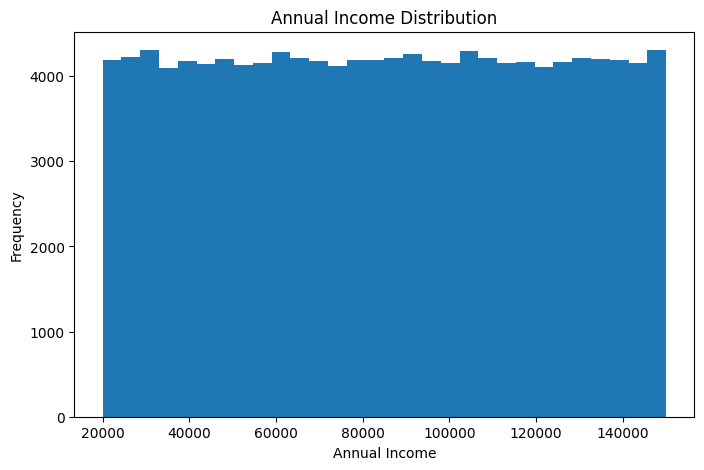

In [45]:
plt.figure(figsize=(8,5))

plt.hist(df["AnnualIncome"], bins=30)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income")

plt.ylabel("Frequency")

plt.show()

(array([6939., 7118., 4766., 7118., 4869., 7192., 7158., 4630., 7115.,
        4713., 7161., 7147., 4762., 7111., 4680., 7165., 7291., 4658.,
        7171., 6990.]),
 array([18. , 20.6, 23.2, 25.8, 28.4, 31. , 33.6, 36.2, 38.8, 41.4, 44. ,
        46.6, 49.2, 51.8, 54.4, 57. , 59.6, 62.2, 64.8, 67.4, 70. ]),
 <BarContainer object of 20 artists>)

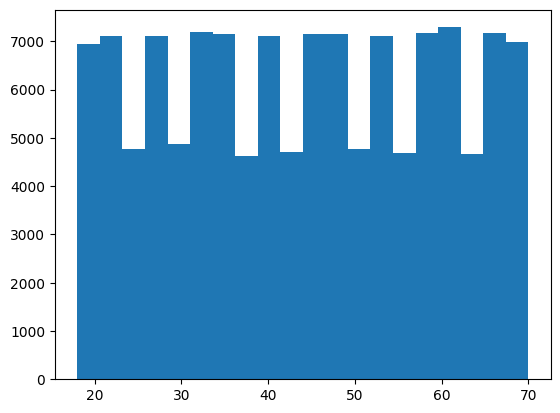

In [46]:
plt.hist(df["Age"], bins=20)

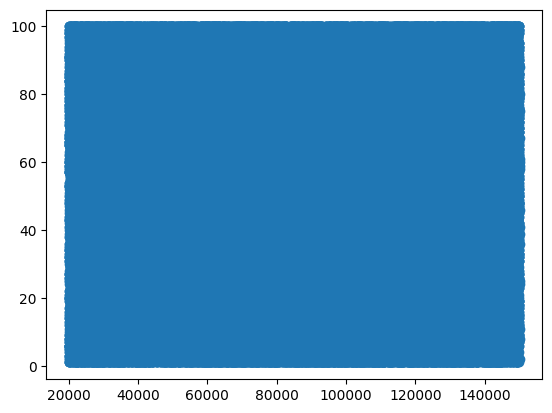

In [47]:
plt.scatter(df["AnnualIncome"],
            df["SpendingScore"])

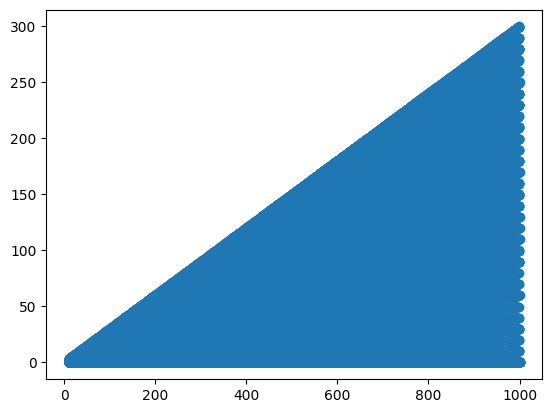

In [48]:
plt.scatter(df["ProductPrice"],
            df["Profit"])

<Axes: ylabel='ProductPrice'>

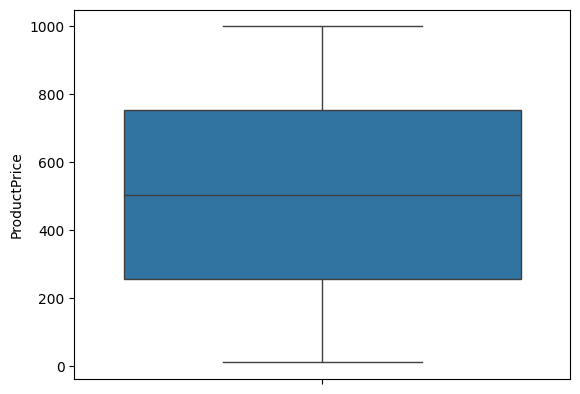

In [49]:
sns.boxplot(y=df["ProductPrice"])

<Axes: ylabel='Profit'>

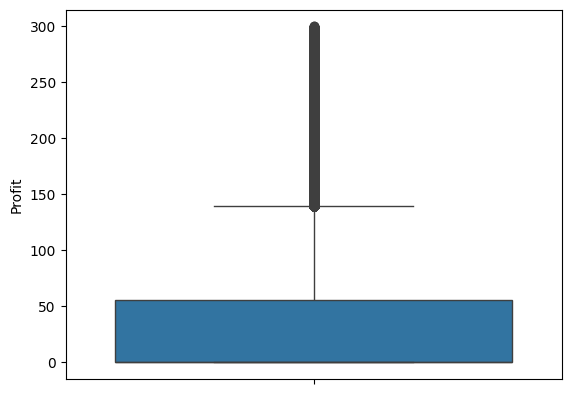

In [50]:
sns.boxplot(y=df["Profit"])

In [51]:
numeric_df = df.select_dtypes(include=np.number)

In [52]:
corr = numeric_df.corr()

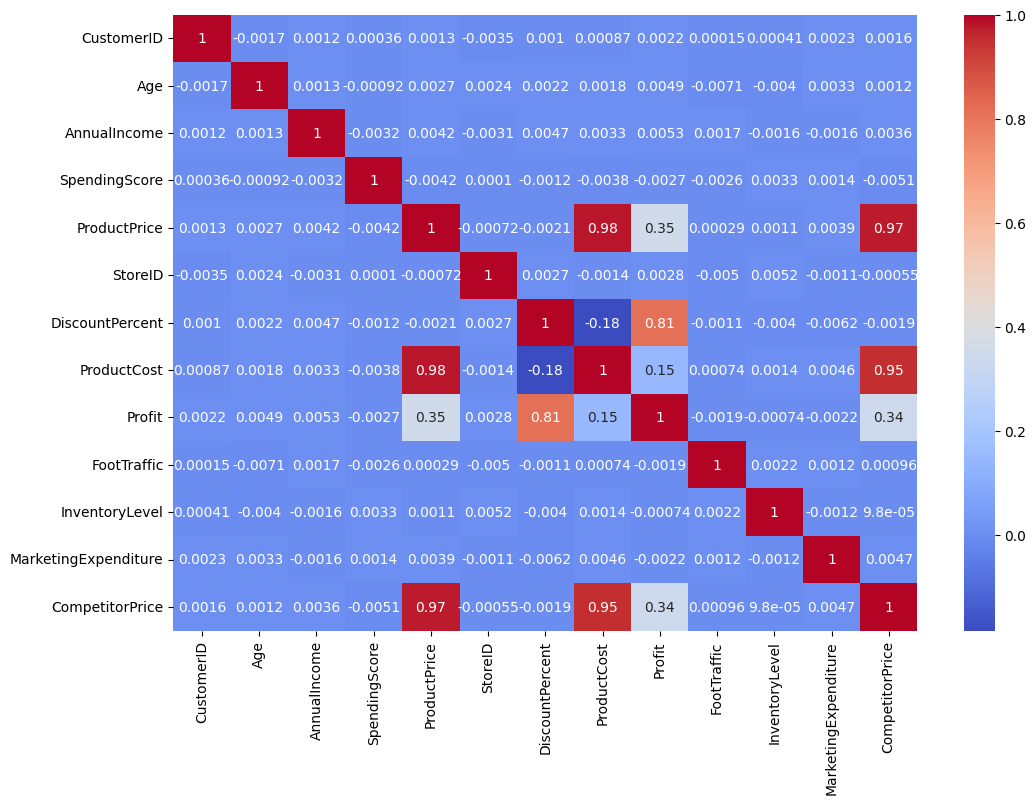

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()